# Visibility Timing Evaluator

This notebook evaluates the four visibility-timing conditions: **G → G**, **G → S**, **S → G**, and **S → S**.

It produces the same dependent-variable set used in the maturity evaluator:

1. Best solution rank
2. Diversity
3. Pairwise solution diversity

For each DV, the notebook produces three figure types:

1. One aggregate line, averaged across all four directional conditions and K values.
2. Two sender-type lines, comparing G as sender and S as sender.
3. Four directional lines, comparing G → G, G → S, S → G, and S → S.

Each figure cell contains the full plotting code directly, without figure-specific plotting wrapper functions.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path

legend_properties = {"weight": "bold"}

# =========================
# Configuration
# =========================
# Change this path to the folder that contains the saved pickle outputs.
result_folder = Path(r"/Volumes/T7/data/gst-0112-26/Timing_8")

agent_num = 200
visibility_start_list = [0, 10, 20, 30, 40, 50, 75, 100, 150, 200, 250, 280, 290]

# Must match visibility_interval in the running scripts.
# The updated scripts save files with `_interval_{visibility_interval}_` in the filename.
visibility_interval = 10

prefixes = ["gg", "gs", "sg", "ss"]
condition_labels = {
    "gg": "G → G",
    "gs": "G → S",
    "sg": "S → G",
    "ss": "S → S",
}

# Same DVs as the maturity evaluator.
dv_labels = {
    "breakthrough_rank": "Best solution rank",
    "diversity": "Diversity",
    "pairwise_diversity": "Pairwise solution diversity",
}

# Black-and-white line styles for publication-friendly figures.
four_line_styles = {
    "gg": {"linestyle": "-",  "marker": "o", "label": "G → G"},
    "gs": {"linestyle": "--", "marker": "s", "label": "G → S"},
    "sg": {"linestyle": "-.", "marker": "^", "label": "S → G"},
    "ss": {"linestyle": ":",  "marker": "D", "label": "S → S"},
}

sender_groups = {
    "G as sender": ["gg", "gs"],
    "S as sender": ["sg", "ss"],
}

sender_styles = {
    "G as sender": {"linestyle": "-",  "marker": "o"},
    "S as sender": {"linestyle": "--", "marker": "v"},
}

figure_size = (7.2, 5.0)


In [2]:
# =========================
# Load results
# =========================
def load_pickle(path):
    with open(path, "rb") as infile:
        return pickle.load(infile)


def result_file(prefix, visibility_start, dv, visibility_interval=visibility_interval):
    return result_folder / (
        f"{prefix}_visibility_start_{visibility_start}_"
        f"interval_{visibility_interval}_{dv}_across_K_size_{agent_num}"
    )


def load_visibility_timing_results(prefixes=prefixes, strict=True):
    """Load timing results into data[prefix][dv].

    Each data[prefix][dv] array has shape:
        visibility start × K, for the configured visibility_interval.

    The plotting cells below average across K, so they are robust to whether
    the running scripts use K=[0,...,8] or K=[1,...,8], as long as each file
    has a consistent K dimension.
    """
    data = {}
    missing_files = []

    for prefix in prefixes:
        data[prefix] = {}
        for dv in dv_labels:
            rows = []
            for visibility_start in visibility_start_list:
                path = result_file(prefix, visibility_start, dv)
                if not path.exists():
                    missing_files.append(path)
                    continue

                values = np.asarray(load_pickle(path), dtype=float)
                rows.append(values)

            if rows:
                data[prefix][dv] = np.vstack(rows)

    if missing_files:
        print("\nMissing files:")
        for path in missing_files[:30]:
            print("  -", path.name)
        if len(missing_files) > 30:
            print(f"  ... and {len(missing_files) - 30} more")

        print("\nPossible causes:")
        print("1. result_folder is not the folder where the scripts saved outputs.")
        print("2. Some scripts have not finished.")
        print("3. agent_num is different from the saved file name.")
        print("4. visibility_interval does not match the saved file name.")
        print("5. File prefix is different, e.g., gg/gs/sg/ss.")
        print("6. pairwise_diversity has not yet been saved by the running scripts.")

        if strict:
            raise FileNotFoundError("Some expected result files are missing.")

    return data


data = load_visibility_timing_results(strict=True)

print("Result folder:", result_folder)
print("Visibility interval:", visibility_interval)
print("Loaded data shapes:")
for prefix in prefixes:
    for dv in dv_labels:
        print(prefix, dv, data[prefix][dv].shape)


Result folder: /Volumes/T7/data/gst-0112-26/Timing_8
Visibility interval: 10
Loaded data shapes:
gg breakthrough_rank (13, 8)
gg diversity (13, 8)
gg pairwise_diversity (13, 8)
gs breakthrough_rank (13, 8)
gs diversity (13, 8)
gs pairwise_diversity (13, 8)
sg breakthrough_rank (13, 8)
sg diversity (13, 8)
sg pairwise_diversity (13, 8)
ss breakthrough_rank (13, 8)
ss diversity (13, 8)
ss pairwise_diversity (13, 8)


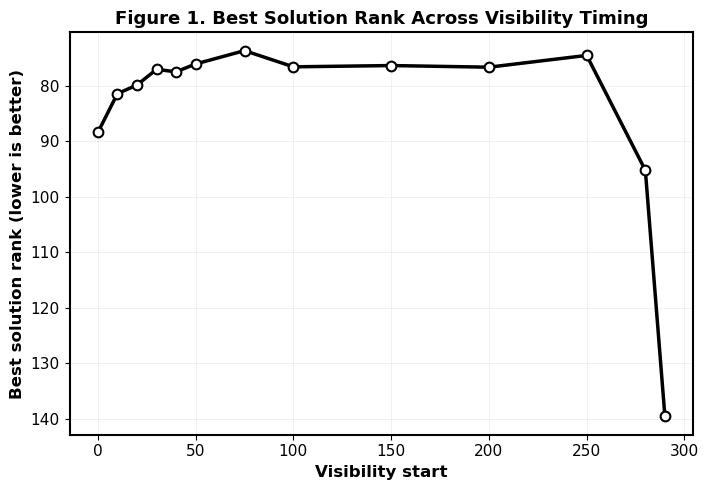

Saved: /Volumes/T7/data/gst-0112-26/Timing_8/figure_1_rank_one_line.png


In [3]:
# =========================
# Figure 1: One line — Best solution rank (lower is better) across visibility timing
# =========================
fig, ax = plt.subplots(figsize=figure_size)

x = visibility_start_list

# First average each condition across K; then average across the four directional conditions.
y = np.mean(
    [data[prefix]["breakthrough_rank"].mean(axis=1) for prefix in prefixes],
    axis=0,
)

ax.plot(
    x, y,
    color="black",
    linestyle="-",
    marker="o",
    linewidth=2.5,
    markersize=7,
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.5,
)

for spine in ["left", "right", "top", "bottom"]:
    ax.spines[spine].set_linewidth(1.5)

ax.grid(alpha=0.25)
ax.tick_params(axis="both", labelsize=11)
ax.invert_yaxis()  # smaller rank means better solution; invert so better is visually higher
ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution rank (lower is better)", fontweight="bold", fontsize=12)
ax.set_title("Figure 1. Best Solution Rank Across Visibility Timing", fontweight="bold", fontsize=13)

fig.tight_layout()
output_path = result_folder / "figure_1_rank_one_line.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


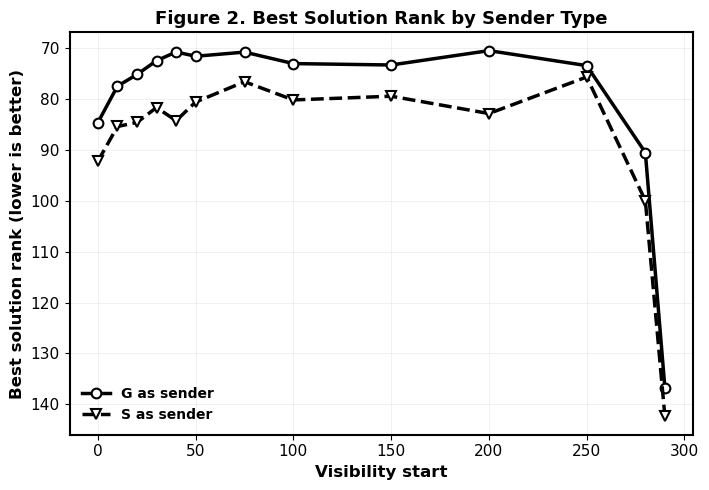

Saved: /Volumes/T7/data/gst-0112-26/Timing_8/figure_2_rank_sender_type.png


In [4]:
# =========================
# Figure 2: Two lines — Best solution rank (lower is better) by sender type
# =========================
fig, ax = plt.subplots(figsize=figure_size)

x = visibility_start_list

for label, selected_prefixes in sender_groups.items():
    # Average across receiver conditions and K.
    # G as sender = average of GG and GS.
    # S as sender = average of SG and SS.
    y = np.mean(
        [data[prefix]["breakthrough_rank"] for prefix in selected_prefixes],
        axis=0,
    ).mean(axis=1)

    ax.plot(
        x, y,
        color="black",
        linestyle=sender_styles[label]["linestyle"],
        marker=sender_styles[label]["marker"],
        linewidth=2.5,
        markersize=7,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        label=label,
    )

for spine in ["left", "right", "top", "bottom"]:
    ax.spines[spine].set_linewidth(1.5)

ax.grid(alpha=0.25)
ax.tick_params(axis="both", labelsize=11)
ax.invert_yaxis()  # smaller rank means better solution; invert so better is visually higher
ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution rank (lower is better)", fontweight="bold", fontsize=12)
ax.set_title("Figure 2. Best Solution Rank by Sender Type", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)

fig.tight_layout()
output_path = result_folder / "figure_2_rank_sender_type.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


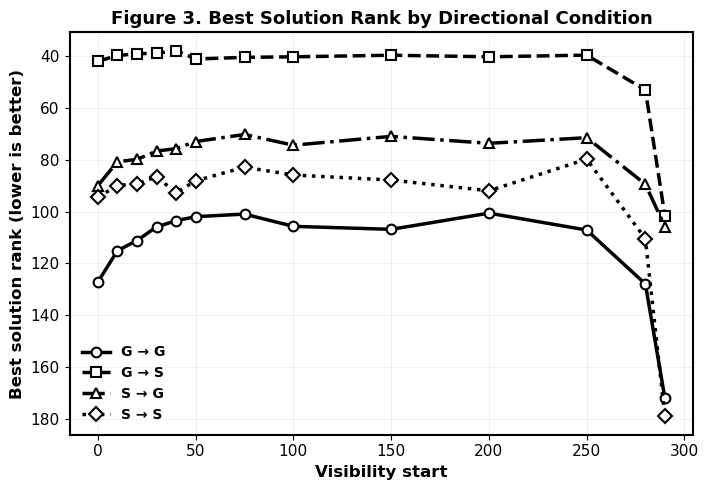

Saved: /Volumes/T7/data/gst-0112-26/Timing_8/figure_3_rank_four_conditions.png


In [5]:
# =========================
# Figure 3: Four lines — Best solution rank (lower is better) by directional condition
# =========================
fig, ax = plt.subplots(figsize=figure_size)

x = visibility_start_list

for prefix in prefixes:
    style = four_line_styles[prefix]

    # Average each directional condition across K.
    y = data[prefix]["breakthrough_rank"].mean(axis=1)

    ax.plot(
        x, y,
        color="black",
        linestyle=style["linestyle"],
        marker=style["marker"],
        linewidth=2.5,
        markersize=7,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        label=style["label"],
    )

for spine in ["left", "right", "top", "bottom"]:
    ax.spines[spine].set_linewidth(1.5)

ax.grid(alpha=0.25)
ax.tick_params(axis="both", labelsize=11)
ax.invert_yaxis()  # smaller rank means better solution; invert so better is visually higher
ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution rank (lower is better)", fontweight="bold", fontsize=12)
ax.set_title("Figure 3. Best Solution Rank by Directional Condition", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)

fig.tight_layout()
output_path = result_folder / "figure_3_rank_four_conditions.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


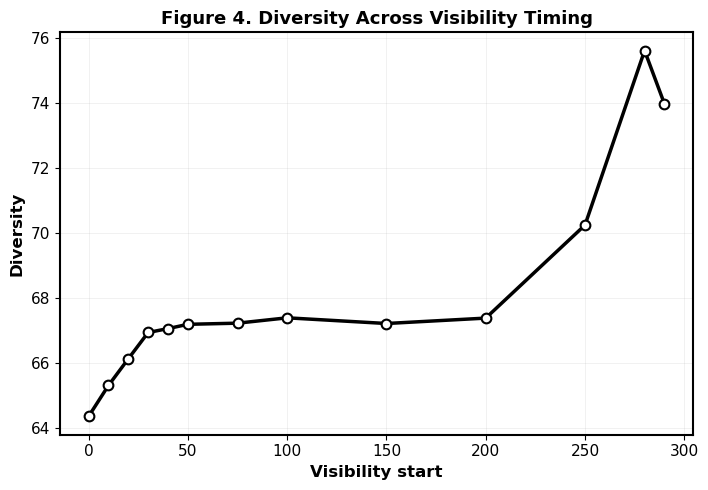

Saved: /Volumes/T7/data/gst-0112-26/Timing_8/figure_4_diversity_one_line.png


In [6]:
# =========================
# Figure 4: One line — Diversity across visibility timing
# =========================
fig, ax = plt.subplots(figsize=figure_size)

x = visibility_start_list

# First average each condition across K; then average across the four directional conditions.
y = np.mean(
    [data[prefix]["diversity"].mean(axis=1) for prefix in prefixes],
    axis=0,
)

ax.plot(
    x, y,
    color="black",
    linestyle="-",
    marker="o",
    linewidth=2.5,
    markersize=7,
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.5,
)

for spine in ["left", "right", "top", "bottom"]:
    ax.spines[spine].set_linewidth(1.5)

ax.grid(alpha=0.25)
ax.tick_params(axis="both", labelsize=11)
ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Diversity", fontweight="bold", fontsize=12)
ax.set_title("Figure 4. Diversity Across Visibility Timing", fontweight="bold", fontsize=13)

fig.tight_layout()
output_path = result_folder / "figure_4_diversity_one_line.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


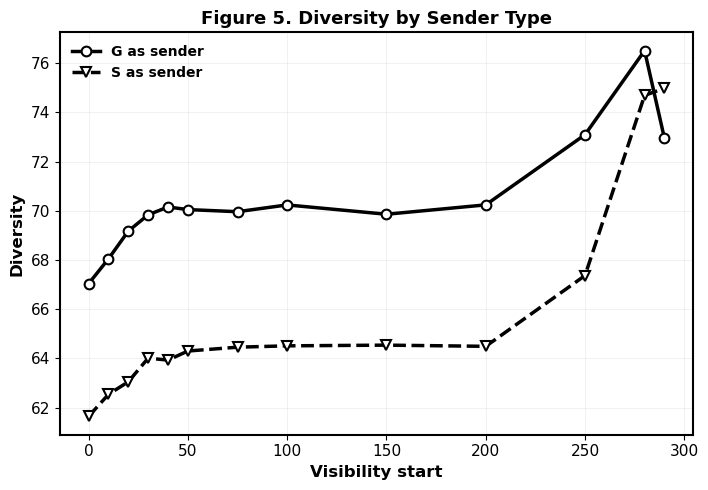

Saved: /Volumes/T7/data/gst-0112-26/Timing_8/figure_5_diversity_sender_type.png


In [7]:
# =========================
# Figure 5: Two lines — Diversity by sender type
# =========================
fig, ax = plt.subplots(figsize=figure_size)

x = visibility_start_list

for label, selected_prefixes in sender_groups.items():
    # Average across receiver conditions and K.
    # G as sender = average of GG and GS.
    # S as sender = average of SG and SS.
    y = np.mean(
        [data[prefix]["diversity"] for prefix in selected_prefixes],
        axis=0,
    ).mean(axis=1)

    ax.plot(
        x, y,
        color="black",
        linestyle=sender_styles[label]["linestyle"],
        marker=sender_styles[label]["marker"],
        linewidth=2.5,
        markersize=7,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        label=label,
    )

for spine in ["left", "right", "top", "bottom"]:
    ax.spines[spine].set_linewidth(1.5)

ax.grid(alpha=0.25)
ax.tick_params(axis="both", labelsize=11)
ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Diversity", fontweight="bold", fontsize=12)
ax.set_title("Figure 5. Diversity by Sender Type", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)

fig.tight_layout()
output_path = result_folder / "figure_5_diversity_sender_type.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


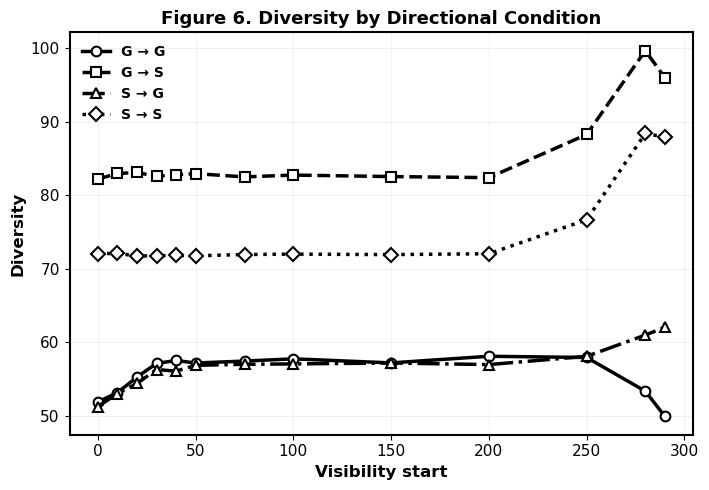

Saved: /Volumes/T7/data/gst-0112-26/Timing_8/figure_6_diversity_four_conditions.png


In [8]:
# =========================
# Figure 6: Four lines — Diversity by directional condition
# =========================
fig, ax = plt.subplots(figsize=figure_size)

x = visibility_start_list

for prefix in prefixes:
    style = four_line_styles[prefix]

    # Average each directional condition across K.
    y = data[prefix]["diversity"].mean(axis=1)

    ax.plot(
        x, y,
        color="black",
        linestyle=style["linestyle"],
        marker=style["marker"],
        linewidth=2.5,
        markersize=7,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        label=style["label"],
    )

for spine in ["left", "right", "top", "bottom"]:
    ax.spines[spine].set_linewidth(1.5)

ax.grid(alpha=0.25)
ax.tick_params(axis="both", labelsize=11)
ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Diversity", fontweight="bold", fontsize=12)
ax.set_title("Figure 6. Diversity by Directional Condition", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)

fig.tight_layout()
output_path = result_folder / "figure_6_diversity_four_conditions.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


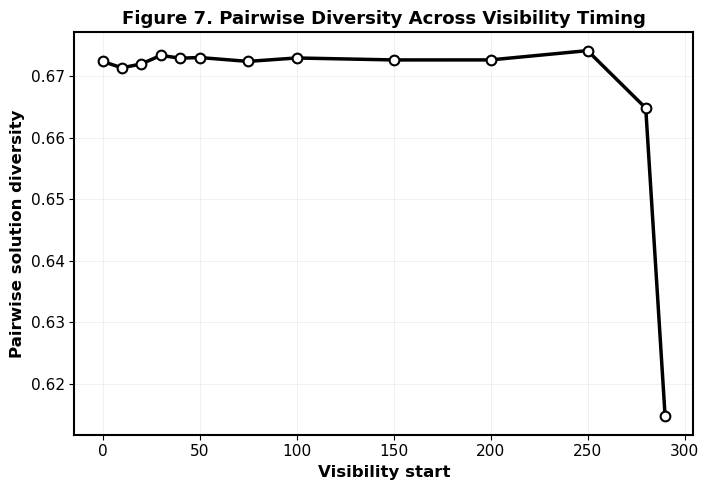

Saved: /Volumes/T7/data/gst-0112-26/Timing_8/figure_7_pairwise_diversity_one_line.png


In [9]:
# =========================
# Figure 7: One line — Pairwise solution diversity across visibility timing
# =========================
fig, ax = plt.subplots(figsize=figure_size)

x = visibility_start_list

# First average each condition across K; then average across the four directional conditions.
y = np.mean(
    [data[prefix]["pairwise_diversity"].mean(axis=1) for prefix in prefixes],
    axis=0,
)

ax.plot(
    x, y,
    color="black",
    linestyle="-",
    marker="o",
    linewidth=2.5,
    markersize=7,
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.5,
)

for spine in ["left", "right", "top", "bottom"]:
    ax.spines[spine].set_linewidth(1.5)

ax.grid(alpha=0.25)
ax.tick_params(axis="both", labelsize=11)
ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Pairwise solution diversity", fontweight="bold", fontsize=12)
ax.set_title("Figure 7. Pairwise Diversity Across Visibility Timing", fontweight="bold", fontsize=13)

fig.tight_layout()
output_path = result_folder / "figure_7_pairwise_diversity_one_line.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


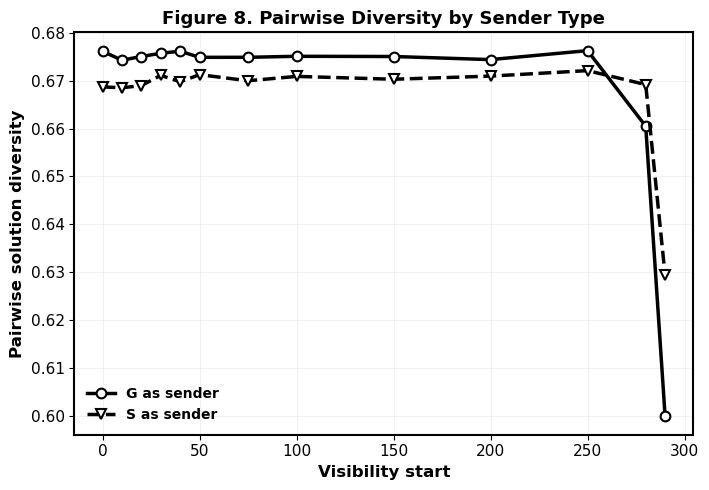

Saved: /Volumes/T7/data/gst-0112-26/Timing_8/figure_8_pairwise_diversity_sender_type.png


In [10]:
# =========================
# Figure 8: Two lines — Pairwise solution diversity by sender type
# =========================
fig, ax = plt.subplots(figsize=figure_size)

x = visibility_start_list

for label, selected_prefixes in sender_groups.items():
    # Average across receiver conditions and K.
    # G as sender = average of GG and GS.
    # S as sender = average of SG and SS.
    y = np.mean(
        [data[prefix]["pairwise_diversity"] for prefix in selected_prefixes],
        axis=0,
    ).mean(axis=1)

    ax.plot(
        x, y,
        color="black",
        linestyle=sender_styles[label]["linestyle"],
        marker=sender_styles[label]["marker"],
        linewidth=2.5,
        markersize=7,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        label=label,
    )

for spine in ["left", "right", "top", "bottom"]:
    ax.spines[spine].set_linewidth(1.5)

ax.grid(alpha=0.25)
ax.tick_params(axis="both", labelsize=11)
ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Pairwise solution diversity", fontweight="bold", fontsize=12)
ax.set_title("Figure 8. Pairwise Diversity by Sender Type", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)

fig.tight_layout()
output_path = result_folder / "figure_8_pairwise_diversity_sender_type.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


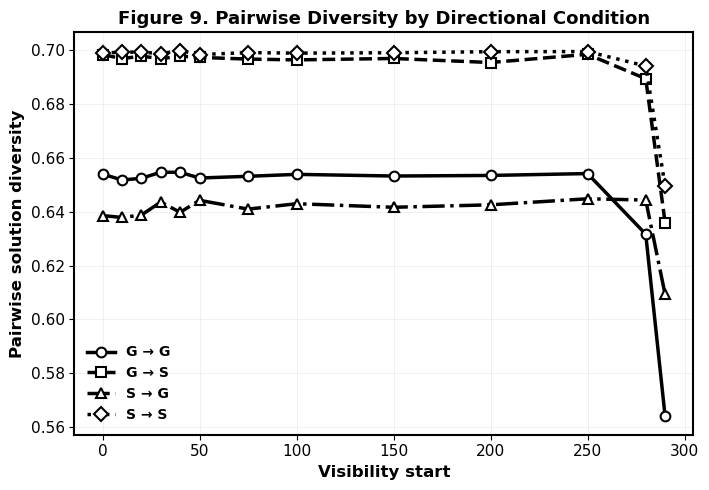

Saved: /Volumes/T7/data/gst-0112-26/Timing_8/figure_9_pairwise_diversity_four_conditions.png


In [11]:
# =========================
# Figure 9: Four lines — Pairwise solution diversity by directional condition
# =========================
fig, ax = plt.subplots(figsize=figure_size)

x = visibility_start_list

for prefix in prefixes:
    style = four_line_styles[prefix]

    # Average each directional condition across K.
    y = data[prefix]["pairwise_diversity"].mean(axis=1)

    ax.plot(
        x, y,
        color="black",
        linestyle=style["linestyle"],
        marker=style["marker"],
        linewidth=2.5,
        markersize=7,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        label=style["label"],
    )

for spine in ["left", "right", "top", "bottom"]:
    ax.spines[spine].set_linewidth(1.5)

ax.grid(alpha=0.25)
ax.tick_params(axis="both", labelsize=11)
ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Pairwise solution diversity", fontweight="bold", fontsize=12)
ax.set_title("Figure 9. Pairwise Diversity by Directional Condition", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)

fig.tight_layout()
output_path = result_folder / "figure_9_pairwise_diversity_four_conditions.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


In [12]:
# =========================
# Optional: inspect exact plotted values as tables
# =========================
columns = [f"timing={value}" for value in visibility_start_list]

plot_tables = {}

for dv in dv_labels:
    plot_tables[dv] = {
        "overall": np.mean(
            [data[prefix][dv].mean(axis=1) for prefix in prefixes],
            axis=0,
        ).round(4).tolist(),
        "G_sender": np.mean(
            [data[prefix][dv] for prefix in ["gg", "gs"]],
            axis=0,
        ).mean(axis=1).round(4).tolist(),
        "S_sender": np.mean(
            [data[prefix][dv] for prefix in ["sg", "ss"]],
            axis=0,
        ).mean(axis=1).round(4).tolist(),
    }

    for prefix in prefixes:
        plot_tables[dv][prefix] = data[prefix][dv].mean(axis=1).round(4).tolist()

print("Columns:")
print(columns)

for dv, table in plot_tables.items():
    print(f"\n{dv} table:")
    for key, values in table.items():
        print(key, values)


Columns:
['timing=0', 'timing=10', 'timing=20', 'timing=30', 'timing=40', 'timing=50', 'timing=75', 'timing=100', 'timing=150', 'timing=200', 'timing=250', 'timing=280', 'timing=290']

breakthrough_rank table:
overall [88.4379, 81.4483, 79.8966, 77.0791, 77.5166, 76.1027, 73.7007, 76.6196, 76.3894, 76.6825, 74.5628, 95.2516, 139.5817]
G_sender [84.6377, 77.4867, 75.1856, 72.4785, 70.7685, 71.6056, 70.7923, 73.0465, 73.3238, 70.5, 73.4462, 90.5281, 136.78]
S_sender [92.2381, 85.41, 84.6075, 81.6796, 84.2646, 80.5998, 76.6092, 80.1927, 79.455, 82.865, 75.6794, 99.975, 142.3833]
gg [127.1533, 115.1029, 111.1771, 105.9262, 103.5354, 101.9867, 100.9917, 105.7112, 106.8671, 100.6258, 107.1421, 127.8979, 171.9208]
gs [42.1221, 39.8704, 39.1942, 39.0308, 38.0017, 41.2246, 40.5929, 40.3817, 39.7804, 40.3742, 39.7504, 53.1583, 101.6392]
sg [90.0117, 80.8267, 79.9129, 76.7196, 75.7633, 73.03, 70.3129, 74.4408, 71.0471, 73.7192, 71.5454, 89.4854, 105.8054]
ss [94.4646, 89.9933, 89.3021, 86.6396, 9